In [34]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Dict, Any, Sequence, Tuple

In [ ]:
def compute_td_u(
    B_pu: float, 
    gamma_pu: float
) -> float:
    """
    TD,U = 1 / (Bp,u * log2(1 + gamma_pu))
    B_pu: bandwidth (bytes/sec) for DU p to user u (or effective bandwidth)
    gamma_pu: average SNR
    returns average latency (seconds) per byte
    """
    denom = B_pu * np.log2(1.0 + max(gamma_pu, 1e-12))
    if denom <= 0: return np.inf
    return 1.0 / denom

def compute_tm_u(
    td_u: float, 
    R_M_D: float, 
    U: int
) -> float:
    """
    TM,U = TD,U + 1 / (R_M,D / U) = TD,U + U / R_M,D
    R_M_D: total data rate from MEC to DU (bytes/sec)
    U: number of users sharing link equally
    returns average latency (seconds) per byte
    """
    if R_M_D <= 0 or U <= 0: return np.inf
    return td_u + (U / R_M_D)

def compute_tc_u(
    tm_u: float, 
    R_C_M: float, 
    U: int
) -> float:
    """
    TC,U = TM,U + 1 / (R_C,M / U) = TM,U + U / R_C,M
    R_C_M: total data rate from Cloud to MEC (bytes/sec)
    """
    if R_C_M <= 0 or U <= 0: return np.inf
    return tm_u + (U / R_C_M)

def compute_ttc(
    rhoT_p: Sequence[float],
    lambda_p: Sequence[float],
    eta: float,
    mu: float
) -> float:
    """
    Ttc = (sum_p rhoT_p * lambda_p / eta) / (mu - sum_p lambda_p)
    Conditions: mu - sum(lambda_p) > 0
    rhoT_p, lambda_p arrays must be same length P
    eta: average data size of computation tasks (bytes)
    mu: service rate of MEC server (bytes/sec of processing capacity)
    returns avg computation latency per byte (seconds/byte)
    """
    rhoT_p = np.asarray(rhoT_p, dtype=float)
    lambda_p = np.asarray(lambda_p, dtype=float)
    if eta <= 0: raise ValueError("eta must be > 0")
    denom = mu - np.sum(lambda_p)
    if denom <= 0: return np.inf
    numerator = np.sum(rhoT_p * lambda_p / eta)
    return numerator / denom

In [ ]:
class LatencyModel:
    """
    LatencyModel computes per-tile latency and total latency for requests
    using the formulas from the paper (TD,U, TM,U, TC,U, Ttc and D matrix).

    P: number of DUs (p in paper)
    U: number of users
    R_M_D: total MEC->DU data rate (bytes/sec)
    R_C_M: total Cloud->MEC data rate (bytes/sec)
    mu: MEC service rate (bytes/sec) for transcoding
    eta: average computation task size (bytes)
    B_pu_matrix: shape (P, U) bandwidths from DU p to user u (bytes/sec). If None, set to 1e6
    gamma_pu_matrix: shape (P, U) SNRs. If None, set to 10 (10 linear)
    rhoT_p: length P list of proportion of transcoding tasks requested at CU
    lambda_p: length P list of arrival rates (requests/sec) from each DU
    """
    def __init__(
        self,
        P: int,
        max_U: int,
        R_M_D: float,
        R_C_M: float,
        mu: float,
        eta: float,
        B_pu_matrix: np.ndarray,
        gamma_pu_matrix: np.ndarray,
        rhoT_p: Sequence[float],
        lambda_p: Sequence[float],
        du_fixed_delay: float,
        mec_fixed_delay: float,
        cloud_fixed_delay: float
    ):
        self.P = P
        self.max_U = max_U
        self.R_M_D = float(R_M_D)
        self.R_C_M = float(R_C_M)
        self.mu = float(mu)
        self.eta = float(eta)

        self.du_fixed_delay = float(du_fixed_delay)
        self.mec_fixed_delay = float(mec_fixed_delay)
        self.cloud_fixed_delay = float(cloud_fixed_delay)

        self.B_pu = np.asarray(B_pu_matrix, dtype=float).reshape(P, max_U)
        self.gamma_pu = np.asarray(gamma_pu_matrix, dtype=float).reshape(P, max_U)
        self.rhoT_p = np.asarray(rhoT_p, dtype=float)
        self.lambda_p = np.asarray(lambda_p, dtype=float)

        # precompute TD,U
        self.TD_U = np.zeros((P, max_U), dtype=float)
        for p in range(P):
            for u in range(max_U):
                self.TD_U[p, u] = compute_td_u(
                    self.B_pu[p, u], 
                    self.gamma_pu[p, u]
                )

    def time_vector(self, p: int, u: int, active_users: int) -> Tuple[float, float, float, float, float]:
        td_u = self.TD_U[p, u]
        tm_u = compute_tm_u(td_u, self.R_M_D, active_users)
        tc_u = compute_tc_u(tm_u, self.R_C_M, active_users)
        ttc = compute_ttc(self.rhoT_p, self.lambda_p, self.eta, self.mu)
        
        return td_u, tm_u, tc_u, tm_u + ttc, tm_u + ttc

    def tile_latency(
        self, 
        p: int, 
        u: int, 
        tile_size_bytes: float, 
        events: Dict[str, int],
        active_users: int
    ) -> float:
        """
        events dict must contain binary flags for:
         - 'alpha_p_u', 'alpha_M_u', 'alpha_C_u', 'beta_p_u', 'beta_M_u'
        Order corresponds to the 5 columns in the paper's D matrix.
        Returns latency in seconds for that tile (per tile_size_bytes).
        """
        T_vec = np.array(
            self.time_vector(p, u, active_users), 
            dtype=float
        )
        ES_vec = np.array([
            events["alpha_p_u"],
            events["alpha_M_u"],
            events["alpha_C_u"],
            events["beta_p_u"],
            events["beta_M_u"],
        ], dtype=float)
        
        per_byte_latency = float(np.dot(ES_vec, T_vec) * tile_size_bytes)

        fixed = 0.0
        if events["alpha_p_u"] == 1 or events["beta_p_u"] == 1:
            fixed += self.du_fixed_delay
        if events["alpha_M_u"] == 1 or events["beta_M_u"] == 1:
            fixed += self.mec_fixed_delay
        if events["alpha_C_u"] == 1:
            fixed += self.cloud_fixed_delay

        return per_byte_latency + fixed

    def total_request_latency(
        self, 
        p: int, 
        u: int, 
        tiles: Sequence[Dict[str, Any]],
        active_users: int
    ) -> Tuple[float, Sequence[Tuple[str, float]]]:
      
        sorted_tiles = sorted(tiles, key=lambda t: t["layer"])
        
        total, tile_latencies = 0.0, []
        for tile in sorted_tiles:
            sz     = float(tile["size"])
            events = tile["events"]
            tid    = tile["tile"]
            layer  = tile["layer"]

            lat = self.tile_latency(p, u, sz, events, active_users)

            if total + lat >= 1.0:
                break
            
            tile_latencies.append((tid, layer, lat))
            total += lat
            
        return total, tile_latencies

    def compute_latency_for_request(
        self, 
        request: Dict[str, Any], 
        active_users: int
    ) -> Dict[str, Any]:
        p = request["p"]
        u = request["u"]
        tiles = request["tiles"]

        total_latency, tile_latencies = self.total_request_latency(
            p, 
            u, 
            tiles,
            active_users
        )
        
        return {
            "total_latency": total_latency,
            "tile_latencies": tile_latencies
        }
    
    def user_link_throughput(
        self, 
        p: int, 
        u: int,
        active_users: int
    ) -> Dict[str, float]:
        """
        Returns per-user throughput (bytes/sec) for each stage:
        - 'du': wireless DU->user
        - 'mec': DU->user + MEC->DU (shared)
        - 'cloud': DU->user + MEC->DU + Cloud->MEC (shared)
        """
        td_u = self.TD_U[p, u]                         # sec/byte
        tm_u = compute_tm_u(td_u, self.R_M_D, active_users)  # sec/byte
        tc_u = compute_tc_u(tm_u, self.R_C_M, active_users)  # sec/byte

        def inv(x): return 0.0 if not np.isfinite(x) or x <= 0 else (1.0 / x)

        return {
            "du": inv(td_u),        # bytes/sec over DU->user link
            "mec": inv(tm_u),       # bytes/sec including MEC->DU
            "cloud": inv(tc_u)      # bytes/sec including Cloud->MEC
        }

    def request_effective_throughput(
        self, 
        p: int, 
        u: int, 
        tiles: Sequence[Dict[str, Any]]
    ) -> float:
        """
        Effective throughput for a request = total_bytes / total_time.
        Uses tile_latency() to accumulate time over all tiles.
        """
        total_bytes = 0.0
        total_time = 0.0
        for tile in tiles:
            sz = float(tile["size"])
            events = tile.get("events", {})
            total_bytes += sz
            total_time += self.tile_latency(p, u, sz, events)
        
        if total_time <= 0 or not np.isfinite(total_time):
            return 0.0
        
        return total_bytes / total_time

In [37]:
if __name__ == "__main__":
    # Create latency model (replace numbers with your real config)
    P = 1; max_U = 30
    lat_model = LatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,       # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9,     # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),    # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {U}\n"
        f"Latency Model Parameters:\n"
        f"  R_M_D = {lat_model.R_M_D} B/s\n"
        f"  R_C_M = {lat_model.R_C_M} B/s\n"
        f"  mu = {lat_model.mu} B/s\n"
        f"  eta = {lat_model.eta} B\n"
        f"  B_pu = {lat_model.B_pu[0,0]} B/s\n"
        f"  gamma_pu = {lat_model.gamma_pu[0,0]}\n"
        f"  rhoT_p = {lat_model.rhoT_p}\n"
        f"  lambda_p = {lat_model.lambda_p}\n"
        f"==============================\n"
    )

    request = {
        "seq": 0,
        "p": 0,
        "u": 0,
        "video": 0,
        "tiles": [
            {
                "tile": 1,
                "layer": 0,
                "size": 12000,
                "events": {
                    "alpha_p_u":1,
                    "alpha_M_u":0,
                    "alpha_C_u":0,
                    "beta_p_u":0,
                    "beta_M_u":0
                }
            },
            {
                "tile": 2, 
                "layer": 0,
                "size": 12000,
                "events": {
                    "alpha_p_u":0,
                    "alpha_M_u":1,
                    "alpha_C_u":0,
                    "beta_p_u":0,
                    "beta_M_u":0
                }
            },
            {
                "tile": 3, 
                "layer": 0,
                "size": 12000,
                "events": {
                    "alpha_p_u":0,
                    "alpha_M_u":0,
                    "alpha_C_u":1,
                    "beta_p_u":0,
                    "beta_M_u":0
                }
            },
        ]
    }

    latency_info = lat_model.compute_latency_for_request(request, active_users=max_U)

    print("User link throughput (bytes/sec):")
    for u in range(max_U):
        tp = lat_model.user_link_throughput(p=0, u=u, active_users=max_U)
        print(
            f" User {u}:"
            f" DU link: {tp['du']:.2f} B/s,"
            f" MEC link: {tp['mec']:.2f} B/s,"
            f" Cloud link: {tp['cloud']:.2f} B/s"
        )

Experiment ===================
Total users: 30
Latency Model Parameters:
  R_M_D = 80000000.0 B/s
  R_C_M = 1250000000.0 B/s
  mu = 20000000.0 B/s
  eta = 200000.0 B
  B_pu = 40000000.0 B/s
  gamma_pu = 5.0
  rhoT_p = [0.2]
  lambda_p = [0.05]

User link throughput (bytes/sec):
 User 0: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 1: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 2: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 3: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 4: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 5: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 6: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 7: DU link: 103398500.03 B/s, MEC link: 2599621.93 B/s, Cloud link: 2446954.19 B/s
 User 8: 

Active Users    | Total Latency (s)   
----------------------------------------
10              | 0.080601
15              | 0.090176
20              | 0.099751
25              | 0.109326
30              | 0.118901
35              | 0.128476
40              | 0.138051
45              | 0.147626
50              | 0.157201
55              | 0.166776
60              | 0.176351
65              | 0.185926
70              | 0.195501
75              | 0.205076
80              | 0.214651
85              | 0.224226
90              | 0.233801
95              | 0.243376
100             | 0.252951


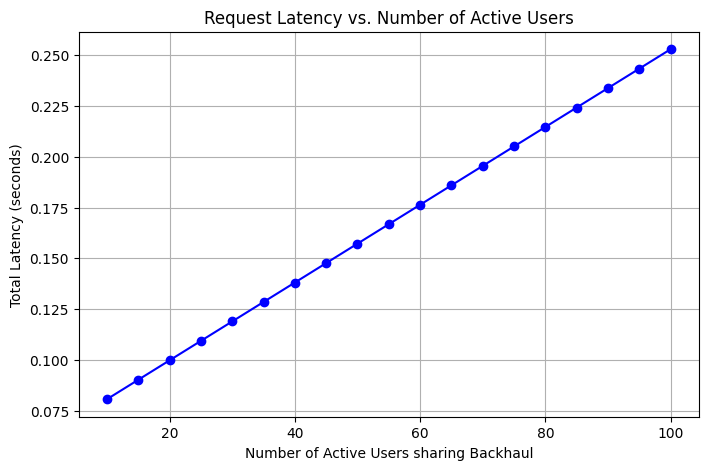


Plot generated successfully.


In [38]:
# ==========================================
# 3. Main Test Block
# ==========================================
if __name__ == "__main__":
    # --- Configuration ---
    P = 1               # Number of DUs
    MAX_USERS = 100     # Maximum possible users in the system
    
    # Instantiate the model
    model = LatencyModel(
        P=P, 
        max_U=MAX_USERS,
        R_M_D=80e6,       # Backhaul MEC->DU: 80 MB/s (640 Mbps)
        R_C_M=1.25e9,     # Backhaul Cloud->MEC: 1.25 GB/s (10 Gbps)
        mu=2e7,           # MEC Service Rate
        eta=2e5,          # Average task size
        B_pu_matrix=np.full((P, MAX_USERS), 40e6, dtype=float), # Wireless BW: 40 MB/s
        gamma_pu_matrix=np.full((P, MAX_USERS), 5.0, dtype=float), # SNR
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1ms
        mec_fixed_delay=0.005,   # 5ms
        cloud_fixed_delay=0.05   # 50ms
    )

    # --- Define a Test Request ---
    # Scenario: User 0 requests 3 tiles. 
    # Tile 1: Served by MEC (Cache hit)
    # Tile 2: Served by Cloud (Cache miss)
    # Tile 3: Served by MEC (Cache hit)
    req_tiles = [
        {
            "tile": 1, 
            "layer": 0, 
            "size": 50000, 
            "events": 
            {
                "alpha_p_u":0, 
                "alpha_M_u":1, 
                "alpha_C_u":0, 
                "beta_p_u":0, "beta_M_u":0
            }
        },
        {
            "tile": 2, 
            "layer": 0, 
            "size": 50000, 
            "events": 
            {
                "alpha_p_u":0, 
                "alpha_M_u":0, 
                "alpha_C_u":1, 
                "beta_p_u":0, 
                "beta_M_u":0
            }
        },
        {
            "tile": 3, 
            "layer": 0, 
            "size": 50000, 
            "events": 
            {
                "alpha_p_u":0, 
                "alpha_M_u":1, 
                "alpha_C_u":0, 
                "beta_p_u":0, 
                "beta_M_u":0
            }
        }
    ]

    test_request = {
        "seq": 101, 
        "p": 0, 
        "u": 0, 
        "tiles": req_tiles
    }

    # --- Simulation Loop ---
    # Simulate a varying number of users from 10 to 100
    user_counts = range(10, 105, 5)
    latencies = []

    print(f"{'Active Users':<15} | {'Total Latency (s)':<20}")
    print("-" * 40)

    for u_count in user_counts:
        # Calculate latency
        result = model.compute_latency_for_request(
            test_request, 
            active_users=u_count
        )
        lat = result["total_latency"]
        latencies.append(lat)
        
        print(f"{u_count:<15} | {lat:.6f}")

    # --- Plotting Results ---
    try:
        plt.figure(figsize=(8, 5))
        plt.plot(user_counts, latencies, marker='o', linestyle='-', color='b')
        plt.title('Request Latency vs. Number of Active Users')
        plt.xlabel('Number of Active Users sharing Backhaul')
        plt.ylabel('Total Latency (seconds)')
        plt.grid(True)
        plt.show()
        print("\nPlot generated successfully.")
    except Exception as e:
        print(f"\nCould not generate plot: {e}")